In [1]:
from transformers import pipeline

# This downloads the model and runs it automatically
classifier = pipeline("sentiment-analysis") 
result = classifier("I absolutely love how easy this library is!")

print(result) 
# Output: [{'label': 'POSITIVE', 'score': 0.99}]

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cuda:0


[{'label': 'POSITIVE', 'score': 0.9995653033256531}]


In [2]:
from transformers import pipeline

pipe = pipeline("image-feature-extraction", model="facebook/dinov3-vitl16-pretrain-lvd1689m")

config.json:   0%|          | 0.00/745 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

Device set to use cuda:0


In [4]:
import os
import glob
import torch
import nibabel as nib
import numpy as np
from PIL import Image
from transformers import AutoImageProcessor, AutoModel
from torch.nn.functional import cosine_similarity

# 1. Setup Device (M1 Mac)
device = torch.device("cuda")

# 2. Load DINOv2
model_id = "facebook/dinov2-base"
processor = AutoImageProcessor.from_pretrained(model_id)
model = AutoModel.from_pretrained(model_id).to(device)
model.eval()

def get_embedding(slice_np):
    """Converts a 2D numpy slice to a DINO embedding."""
    # Normalize slice to 0-255 for the vision model
    slice_min, slice_max = np.percentile(slice_np, [1, 99]) # Robust scaling
    slice_np = np.clip((slice_np - slice_min) / (slice_max - slice_min) * 255, 0, 255).astype(np.uint8)
    
    # Convert grayscale to RGB (DINO expects 3 channels)
    img = Image.fromarray(slice_np).convert("RGB")
    
    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Use the [CLS] token as the global embedding
    return outputs.last_hidden_state[:, 0, :]

def process_subject(subject_path):
    """Extracts embeddings for T1 and T2 middle slices."""
    embeddings = {}
    for modality in ['t1', 't2']:
        # Search for .nii or .nii.gz in the 'image' folder
        img_pattern = os.path.join(subject_path, modality, "image", "*.nii*")
        files = glob.glob(img_pattern)
        
        if not files:
            continue
            
        img_nifti = nib.load(files[0])
        data = img_nifti.get_fdata()
        
        # Get middle indices
        mid_x, mid_y, mid_z = [s // 2 for s in data.shape]
        
        # Extract 3 orthogonal middle slices
        slices = {
            "sagittal": data[mid_x, :, :],
            "coronal": data[:, mid_y, :],
            "axial": data[:, :, mid_z]
        }
        
        embeddings[modality] = {plane: get_embedding(slc) for plane, slc in slices.items()}
    return embeddings

# 3. Main Logic
base_path = "/data/natalia/ADNI_registered/"
subjects = [f.path for f in os.scandir(base_path) if f.is_dir()]

all_data = {}
print(f"Processing {len(subjects)} subjects...")

for subj_path in subjects[:5]: # Testing with first 5 subjects
    subj_id = os.path.basename(subj_path)
    all_data[subj_id] = process_subject(subj_path)



Processing 1796 subjects...


In [5]:
# 4. Compare Similarity (Safe Version)
print("\n--- Results ---")
subj_list = list(all_data.keys())

for i, subj_a in enumerate(subj_list):
    data_a = all_data[subj_a]
    
    # 1. Same Person Similarity (T1 vs T2)
    # Check if BOTH t1 and t2 exist for this person
    if 't1' in data_a and 't2' in data_a:
        # We also check if 'axial' exists just in case
        if 'axial' in data_a['t1'] and 'axial' in data_a['t2']:
            sim = cosine_similarity(data_a['t1']['axial'], 
                                    data_a['t2']['axial']).item()
            print(f"✅ Same Subject ({subj_a}) T1 vs T2 Axial Similarity: {sim:.4f}")
    else:
        missing = [m for m in ['t1', 't2'] if m not in data_a]
        print(f"⚠️  Skipping Same-Subject for {subj_a}: Missing {missing}")

    # 2. Different Person Similarity (Subj A T1 vs Subj B T1)
    if i + 1 < len(subj_list):
        subj_b = subj_list[i+1]
        data_b = all_data[subj_b]
        
        # Ensure both subjects actually have a T1 axial slice
        if 't1' in data_a and 't1' in data_b:
            sim_diff = cosine_similarity(data_a['t1']['axial'], 
                                         data_b['t1']['axial']).item()
            print(f"👥 Diff Subject ({subj_a} vs {subj_b}) T1 Axial Similarity: {sim_diff:.4f}")
        else:
            print(f"⏭️  Skipping Diff-Subject ({subj_a} vs {subj_b}): One is missing T1")


--- Results ---
⚠️  Skipping Same-Subject for 130_S_4415: Missing ['t1', 't2']
⏭️  Skipping Diff-Subject (130_S_4415 vs 009_S_4612): One is missing T1
⚠️  Skipping Same-Subject for 009_S_4612: Missing ['t1', 't2']
⏭️  Skipping Diff-Subject (009_S_4612 vs 005_S_10646): One is missing T1
⚠️  Skipping Same-Subject for 005_S_10646: Missing ['t1', 't2']
⏭️  Skipping Diff-Subject (005_S_10646 vs 033_S_4177): One is missing T1
⚠️  Skipping Same-Subject for 033_S_4177: Missing ['t1', 't2']
⏭️  Skipping Diff-Subject (033_S_4177 vs 073_S_10074): One is missing T1
⚠️  Skipping Same-Subject for 073_S_10074: Missing ['t1', 't2']


In [13]:
import os
import glob
import torch
import nibabel as nib
import numpy as np
from PIL import Image
from tqdm import tqdm
from transformers import AutoImageProcessor, AutoModel
from torch.utils.data import Dataset, DataLoader

# --- CONFIGURATION ---
BASE_PATH = "/data/natalia/ADNI_registered/"
OUTPUT_FILE = "dino_embeddings_all.pt"
BATCH_SIZE = 1 # Keep at 1 for NIfTI as they vary in size/loading time
DEVICE = torch.device("cuda")

# --- 1. THE DATASET CLASS ---
class BrainDataset(Dataset):
    def __init__(self, base_path):
        self.subjects = [f.path for f in os.scandir(base_path) if f.is_dir()][:200]
        self.processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")

    def __len__(self):
        return len(self.subjects)

    def _prep_slice(self, slice_np):
        # Normalize and convert to RGB for DINO
        slice_min, slice_max = np.percentile(slice_np, [1, 99])
        slice_np = np.clip((slice_np - slice_min) / (slice_max - slice_min) * 255, 0, 255).astype(np.uint8)
        return Image.fromarray(slice_np).convert("RGB")

    def __getitem__(self, idx):
        subj_path = self.subjects[idx]
        subj_id = os.path.basename(subj_path)
        data_out = {"id": subj_id, "t1": {}, "t2": {}}

        for mod in ['t1', 't2']:
            # Search for files - using recursive glob in case ADNI folders are deep
            files = glob.glob(os.path.join(subj_path, mod,  "**/*.nii*"), recursive=True)
            files = files[:200]
            if not files: continue

            try:
                img = nib.load(files[0])
                data = img.get_fdata()
                mid = [s // 2 for s in data.shape]

                # Extract slices and process
                slices = {
                    "sagittal": self._prep_slice(data[mid[0], :, :]),
                    "coronal": self._prep_slice(data[:, mid[1], :]),
                    "axial": self._prep_slice(data[:, :, mid[2]])
                }
                
                # Turn images into pixel values
                for plane, img_pil in slices.items():
                    data_out[mod][plane] = self.processor(images=img_pil, return_tensors="pt")["pixel_values"].squeeze(0)
            except Exception as e:
                print(f"Error loading {subj_id} {mod}: {e}")
        
        return data_out

# --- 2. THE PROCESSING LOOP ---
def run_inference():
    dataset = BrainDataset(BASE_PATH)
    # num_workers=4 lets the CPU work in parallel
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, num_workers=4, collate_fn=lambda x: x)
    
    model = AutoModel.from_pretrained("facebook/dinov2-base").to(DEVICE)
    model.eval()

    all_embeddings = {}

    print(f"🚀 Starting processing for {len(dataset)} subjects...")
    for batch in tqdm(dataloader):
        for subject_data in batch:
            subj_id = subject_data["id"]
            all_embeddings[subj_id] = {}

            for mod in ['t1', 't2']:
                if not subject_data[mod]: continue
                all_embeddings[subj_id][mod] = {}
                
                for plane in ['sagittal', 'coronal', 'axial']:
                    pixel_values = subject_data[mod][plane].unsqueeze(0).to(DEVICE)
                    
                    with torch.no_grad():
                        outputs = model(pixel_values)
                        # Store as CPU numpy to save GPU/System RAM
                        embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()
                        all_embeddings[subj_id][mod][plane] = embedding

    # Save results
    torch.save(all_embeddings, OUTPUT_FILE)
    print(f"✅ Finished! Embeddings saved to {OUTPUT_FILE}")

if __name__ == "__main__":
    run_inference()

🚀 Starting processing for 200 subjects...


100%|██████████| 200/200 [00:36<00:00,  5.47it/s]

✅ Finished! Embeddings saved to dino_embeddings_all.pt


In [18]:
results = torch.load("dino_embeddings_all.pt", weights_only=False)
# results['002_S_4473']['t1']['axial'] is now a simple array you can compare!

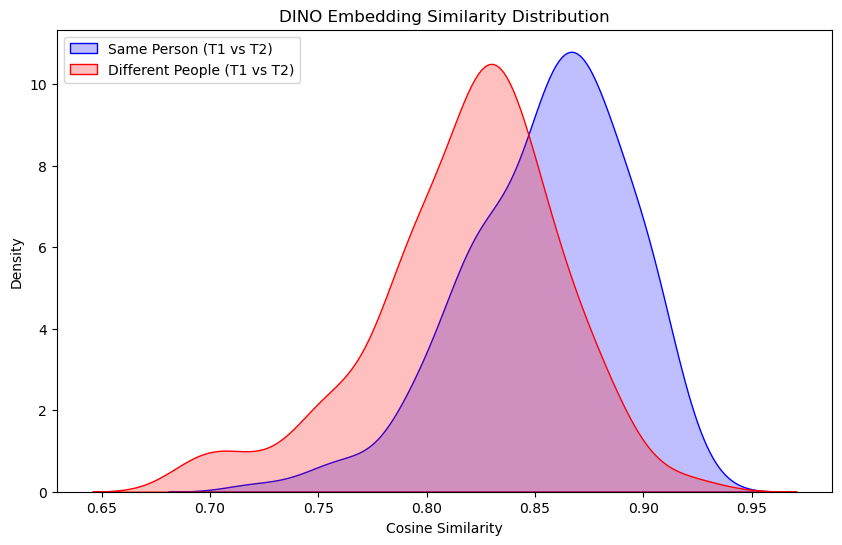

In [23]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from torch.nn.functional import cosine_similarity

# Load the data we saved in the previous step
data = torch.load("dino_embeddings_all.pt", weights_only=False)
subj_ids = list(data.keys())

same_subj_sims = []
diff_subj_sims = []

# 1. Collect Same-Subject Similarities (T1 Axial vs T2 Axial)
for s_id in subj_ids:
    if 't1' in data[s_id] and 't2' in data[s_id]:
        t1 = torch.from_numpy(data[s_id]['t1']['axial'])
        t2 = torch.from_numpy(data[s_id]['t2']['axial'])
        sim = cosine_similarity(t1, t2).item()
        same_subj_sims.append(sim)

# 2. Collect Different-Subject Similarities (T1 Axial vs Random Other T1 Axial)
for i in range(len(subj_ids) - 1):
    s_a, s_b = subj_ids[i], subj_ids[i+1]
    if 't1' in data[s_a] and 't2' in data[s_b]:
        t1_a = torch.from_numpy(data[s_a]['t1']['axial'])
        t1_b = torch.from_numpy(data[s_b]['t2']['axial'])
        sim = cosine_similarity(t1_a, t1_b).item()
        diff_subj_sims.append(sim)

# 3. Plotting
plt.figure(figsize=(10, 6))
sns.kdeplot(same_subj_sims, label="Same Person (T1 vs T2)", fill=True, color="blue")
sns.kdeplot(diff_subj_sims, label="Different People (T1 vs T2)", fill=True, color="red")
plt.title("DINO Embedding Similarity Distribution")
plt.xlabel("Cosine Similarity")
plt.ylabel("Density")
plt.legend()
plt.show()

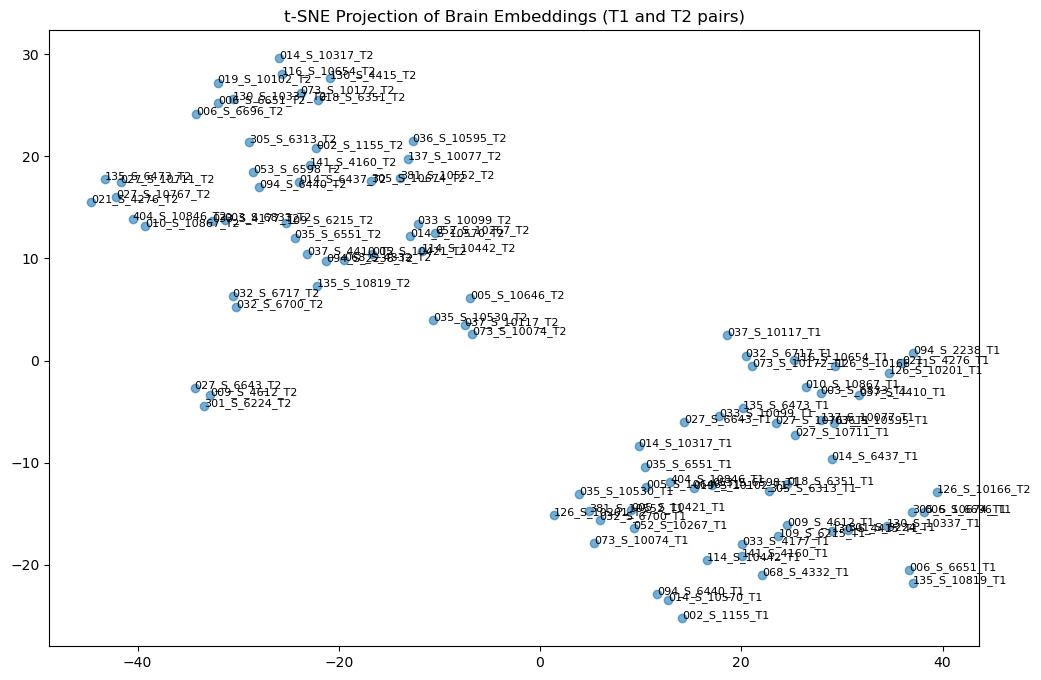

In [21]:
from sklearn.manifold import TSNE

all_vectors = []
labels = []

# Prepare data for t-SNE (Top 50 subjects for clarity)
for s_id in subj_ids[:50]:
    if 't1' in data[s_id] and 't2' in data[s_id]:
        all_vectors.append(data[s_id]['t1']['axial'].flatten())
        labels.append(f"{s_id}_T1")
        all_vectors.append(data[s_id]['t2']['axial'].flatten())
        labels.append(f"{s_id}_T2")

# Run t-SNE
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
embeddings_2d = tsne.fit_transform(np.array(all_vectors))

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6)

# Annotate points to see the pairs
for i, label in enumerate(labels):
    plt.annotate(label, (embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=8)

plt.title("t-SNE Projection of Brain Embeddings (T1 and T2 pairs)")
plt.show()